# Hurricane Milton (2024) — AI Model Track Comparison

Compare tropical cyclone tracks from **AIFS** and **GraphCast**
against ERA5 reanalysis for Hurricane Milton, at three lead times before
landfall (T−72 h, T−168 h, T−240 h).

**Verification target:** Milton's Florida Gulf Coast landfall (Siesta Key),
snapped to `2024-10-10 00:00 UTC`.

| Lead | Init time (UTC)  | Steps (6 h) |
|------|------------------|-------------|
| 72 h | 2024-10-07 00:00 | 12          |
| 168 h| 2024-10-03 00:00 | 28          |
| 240 h| 2024-09-30 00:00 | 40          |

In [1]:
import os

# Must be set BEFORE importing torch.
os.environ["FORCE_CUDA_EXTENSION"] = "1"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
os.environ["CUDA_HOME"] = "/usr/local/cuda"
os.environ["EARTH2STUDIO_CACHE"] = os.path.expanduser("~/.cache/earth2studio")
os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"  # Disable GPU Direct Storage (not available in containers)

for k in ["FORCE_CUDA_EXTENSION", "TORCH_CUDA_ARCH_LIST", "CUDA_HOME", "EARTH2STUDIO_CACHE"]:
    print(f"  {k} = {os.environ[k]}")
print("DONE")

  FORCE_CUDA_EXTENSION = 1
  TORCH_CUDA_ARCH_LIST = 8.9
  CUDA_HOME = /usr/local/cuda
  EARTH2STUDIO_CACHE = /home/jovyan/.cache/earth2studio
DONE

In [2]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import torch
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

from earth2studio.models.px import AIFS
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import ARCO, CDS, fetch_data, prep_data_array
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("Done")

/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead. parsing error, invalid json config /dev/null
 failed to load user config: /dev/null Invalid argument
 cuFile configuration load error
 cuFile initialization failed
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this featureDevice: cudaGPU   : NVIDIA L40
VRAM  : 47.7 GB
Done

In [3]:
# ── Storm & experiment configuration ──────────────────────────────────
STORM_NAME = "Milton"

# Landfall snapped to nearest 6h boundary.
VERIFICATION_TIME = datetime(2024, 10, 10, 0)

# Lead times in hours before VERIFICATION_TIME.
LEAD_TIMES_H = [72, 168, 240]

# Derived: init time and step count for each lead.
INIT_TIMES = {h: VERIFICATION_TIME - timedelta(hours=h) for h in LEAD_TIMES_H}
N_STEPS    = {h: h // 6 for h in LEAD_TIMES_H}

# Output directory — all .pt track files and plots go here.
OUT_DIR = Path("./outputs/milton")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot extent (lon_min, lon_max, lat_min, lat_max).
PLOT_EXTENT = (-100, -65, 15, 40)

# Landfall point: Siesta Key, FL.
LANDFALL_LAT = 27.3
LANDFALL_LON = -82.5

MODEL_COLORS = {
    "AIFS":      "#2ca02c",  # green
    "GraphCast": "#1f77b4",  # blue
    "ERA5":      "#000000",  # black (reanalysis truth)
}

for h in LEAD_TIMES_H:
    print(f"  T-{h:>3}h : init={INIT_TIMES[h]}  steps={N_STEPS[h]}")

  T- 72h : init=2024-10-07 00:00:00  steps=12
  T-168h : init=2024-10-03 00:00:00  steps=28
  T-240h : init=2024-09-30 00:00:00  steps=40

## Helper functions

`TCTrackerWuDuan` runs **during** inference. At each 6 h autoregressive step the
model state is passed to the tracker, which updates its path buffer. Output shape:
`(batch, num_paths, time_steps, 4)` — `[tc_lat, tc_lon, tc_msl, tc_w10m]`.

In [4]:
def run_tc_inference(prognostic, data_source, start_time, nsteps, save_path):
    """Run a prognostic model through TCTrackerWuDuan and save tracks."""
    if Path(save_path).exists():
        print(f"  cached \u2192 {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    prognostic = prognostic.to(DEVICE)
    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  \u2192 {save_path}")
    return tracks

In [24]:
def run_era5_truth(data_source, start_time, nsteps, save_path):
    """Track ERA5 reanalysis through TCTrackerWuDuan step-by-step."""
    if Path(save_path).exists():
        print(f"  cached \u2192 {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    times = [start_time + timedelta(hours=6 * i) for i in range(nsteps + 1)]
    for step, time in tqdm(enumerate(times), total=len(times)):
        da = data_source(time, tracker.input_coords()["variable"])
        x, coords = prep_data_array(da, device=DEVICE)
        output, _ = tracker(x, coords)

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  \u2192 {save_path}")
    return tracks

In [26]:
# ARCO ERA5 — used for FCN3/ERA5 truth (atmospheric vars only).
data_source = ARCO(cache=True)

2026-05-04 22:34:43.019 | DEBUG    | earth2studio.data.arco:_async_init:127 - Using Multi-Storage Client for ARCO data access

In [7]:
# CDS ERA5 — required for AIFS (needs soil moisture/temperature vars not in ARCO).
aifs_data_source = CDS(cache=True)

## AIFS forecasts

AIFS (ECMWF) — GNN encoder + sliding-window transformer processor.
First ML model fully operational at a major NWP center (Feb 2025).

In [8]:
%%time
aifs = AIFS.load_model(AIFS.load_default_package())

CPU times: user 5.7 s, sys: 611 ms, total: 6.31 s
Wall time: 6.29 s

In [9]:
%%time
aifs_tracks_72 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "aifs_72h.pt",
)

2026-05-04 19:17:04.125 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2024-10-06 18:00:00 with 1 levels2026-05-04 19:17:05.339 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:447a2c8e-181d-43af-891f-b47b1e94b93f, state: accepted2026-05-04 19:17:07.523 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:447a2c8e-181d-43af-891f-b47b1e94b93f, state: accepted2026-05-04 19:17:09.705 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:447a2c8e-181d-43af-891f-b47b1e94b93f, state: accepted2026-05-04 19:17:11.894 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:447a2c8e-181d-43af-891f-b47b1e94b93f, state: accepted2026-05-04 19:17:14.079 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:447a2c8e-181d-43af-891f-b47b1e94b93f, state: accepted2026-05-04 19:17:16.252 | DEBUG    | earth2studi

2026-05-04 19:18:04.563 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2024-10-06 18:00:00 with 1 levels2026-05-04 19:18:07.273 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f5c66d84-84f4-47f0-99fb-1b23808ca65f, state: accepted2026-05-04 19:18:09.467 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f5c66d84-84f4-47f0-99fb-1b23808ca65f, state: accepted2026-05-04 19:18:11.645 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f5c66d84-84f4-47f0-99fb-1b23808ca65f, state: accepted2026-05-04 19:18:13.830 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f5c66d84-84f4-47f0-99fb-1b23808ca65f, state: accepted2026-05-04 19:18:16.002 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f5c66d84-84f4-47f0-99fb-1b23808ca65f, state: accepted2026-05-04 19:18:18.190 | DEBUG    | earth2studi

2026-05-04 19:18:36.442 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2024-10-06 18:00:00 with 1 levels2026-05-04 19:18:37.211 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5ddd34af-c0c1-4f1e-bcb8-9f8f7ac017e7, state: accepted2026-05-04 19:18:39.399 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5ddd34af-c0c1-4f1e-bcb8-9f8f7ac017e7, state: accepted2026-05-04 19:18:41.572 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5ddd34af-c0c1-4f1e-bcb8-9f8f7ac017e7, state: accepted2026-05-04 19:18:43.744 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5ddd34af-c0c1-4f1e-bcb8-9f8f7ac017e7, state: accepted2026-05-04 19:18:45.934 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5ddd34af-c0c1-4f1e-bcb8-9f8f7ac017e7, state: accepted2026-05-04 19:18:48.116 | DEBUG    | earth2studi

2026-05-04 19:18:59.222 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_temperature at 2024-10-06 18:00:00 with 1 levels2026-05-04 19:19:00.069 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9102628f-9fac-4356-9a8f-c7b60c7c0518, state: accepted2026-05-04 19:19:02.247 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9102628f-9fac-4356-9a8f-c7b60c7c0518, state: accepted2026-05-04 19:19:04.418 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9102628f-9fac-4356-9a8f-c7b60c7c0518, state: accepted2026-05-04 19:19:06.589 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9102628f-9fac-4356-9a8f-c7b60c7c0518, state: accepted2026-05-04 19:19:08.759 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9102628f-9fac-4356-9a8f-c7b60c7c0518, state: accepted2026-05-04 19:19:10.931 | DEBUG    | earth2studio.data.cd

2026-05-04 19:19:22.304 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2024-10-06 18:00:00 with 1 levels2026-05-04 19:19:23.536 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3bce1cd5-49b9-428e-af7c-8c683910827d, state: accepted2026-05-04 19:19:25.708 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3bce1cd5-49b9-428e-af7c-8c683910827d, state: accepted2026-05-04 19:19:28.898 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3bce1cd5-49b9-428e-af7c-8c683910827d, state: accepted2026-05-04 19:19:31.107 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3bce1cd5-49b9-428e-af7c-8c683910827d, state: accepted2026-05-04 19:19:33.295 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3bce1cd5-49b9-428e-af7c-8c683910827d, state: accepted2026-05-04 19:19:35.499 | DEBUG    | earth2studi

...

2026-05-04 19:32:41.580 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: volumetric_soil_water_layer_2 at 2024-10-07 00:00:00 with 1 levels2026-05-04 19:32:42.392 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fa2c98dd-595e-46f0-866b-ef4ae3af6308, state: accepted2026-05-04 19:32:44.566 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fa2c98dd-595e-46f0-866b-ef4ae3af6308, state: accepted2026-05-04 19:32:46.738 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fa2c98dd-595e-46f0-866b-ef4ae3af6308, state: accepted2026-05-04 19:32:48.908 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fa2c98dd-595e-46f0-866b-ef4ae3af6308, state: accepted2026-05-04 19:32:52.658 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fa2c98dd-595e-46f0-866b-ef4ae3af6308, state: accepted2026-05-04 19:32:54.829 | DEBUG    | earth

2026-05-04 19:33:06.017 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_1 at 2024-10-07 00:00:00 with 1 levels2026-05-04 19:33:06.878 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4e828432-1035-4483-8d15-353daaf39bcd, state: accepted2026-05-04 19:33:09.050 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4e828432-1035-4483-8d15-353daaf39bcd, state: accepted2026-05-04 19:33:11.224 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4e828432-1035-4483-8d15-353daaf39bcd, state: accepted2026-05-04 19:33:13.422 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4e828432-1035-4483-8d15-353daaf39bcd, state: accepted2026-05-04 19:33:15.596 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4e828432-1035-4483-8d15-353daaf39bcd, state: accepted2026-05-04 19:33:17.785 | DEBUG    | earth2stud

2026-05-04 19:33:26.780 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_2 at 2024-10-07 00:00:00 with 1 levels2026-05-04 19:33:27.639 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:85d663ad-8586-4da4-b70e-681153681eec, state: accepted2026-05-04 19:33:29.812 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:85d663ad-8586-4da4-b70e-681153681eec, state: accepted2026-05-04 19:33:31.999 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:85d663ad-8586-4da4-b70e-681153681eec, state: accepted2026-05-04 19:33:34.170 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:85d663ad-8586-4da4-b70e-681153681eec, state: accepted2026-05-04 19:33:36.357 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:85d663ad-8586-4da4-b70e-681153681eec, state: accepted2026-05-04 19:33:38.543 | DEBUG    | earth2stud

 92%|█████████▏| 12/13 [00:11<00:00,  1.00it/s]

  saved  → outputs/milton/aifs_72h.pt
CPU times: user 16.6 s, sys: 2.38 s, total: 19 s
Wall time: 17min 7s

In [10]:
%%time
aifs_tracks_168 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "aifs_168h.pt",
)

2026-05-04 21:29:33.882 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2024-10-02 18:00:00 with 1 levels2026-05-04 21:29:37.129 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:84b7673f-db9b-411f-9902-9a105be04f7e, state: accepted2026-05-04 21:29:39.339 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:84b7673f-db9b-411f-9902-9a105be04f7e, state: accepted2026-05-04 21:29:41.508 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:84b7673f-db9b-411f-9902-9a105be04f7e, state: accepted2026-05-04 21:29:43.677 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:84b7673f-db9b-411f-9902-9a105be04f7e, state: accepted2026-05-04 21:29:45.867 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:84b7673f-db9b-411f-9902-9a105be04f7e, state: accepted2026-05-04 21:29:48.057 | DEBUG    | earth2studi

2026-05-04 21:30:11.707 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2024-10-02 18:00:00 with 1 levels2026-05-04 21:30:16.141 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:54ffa075-c60a-43ca-8d9d-0860b5f5e59b, state: accepted2026-05-04 21:30:18.318 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:54ffa075-c60a-43ca-8d9d-0860b5f5e59b, state: accepted2026-05-04 21:30:20.506 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:54ffa075-c60a-43ca-8d9d-0860b5f5e59b, state: accepted2026-05-04 21:30:22.675 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:54ffa075-c60a-43ca-8d9d-0860b5f5e59b, state: accepted2026-05-04 21:30:24.848 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:54ffa075-c60a-43ca-8d9d-0860b5f5e59b, state: accepted2026-05-04 21:30:27.024 | DEBUG    | earth2studi

2026-05-04 21:30:44.536 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2024-10-02 18:00:00 with 1 levels2026-05-04 21:30:45.393 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a62eaa26-d0a3-44ff-8897-c09475f97637, state: accepted2026-05-04 21:30:47.822 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a62eaa26-d0a3-44ff-8897-c09475f97637, state: accepted2026-05-04 21:30:50.006 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a62eaa26-d0a3-44ff-8897-c09475f97637, state: accepted2026-05-04 21:30:52.183 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a62eaa26-d0a3-44ff-8897-c09475f97637, state: accepted2026-05-04 21:30:54.413 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a62eaa26-d0a3-44ff-8897-c09475f97637, state: accepted2026-05-04 21:30:57.003 | DEBUG    | earth2studi

2026-05-04 21:31:13.305 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_temperature at 2024-10-02 18:00:00 with 1 levels2026-05-04 21:31:14.075 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a7c5b2a2-c7ad-4398-afd4-a6e232f621ca, state: accepted2026-05-04 21:31:16.256 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a7c5b2a2-c7ad-4398-afd4-a6e232f621ca, state: accepted2026-05-04 21:31:18.426 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a7c5b2a2-c7ad-4398-afd4-a6e232f621ca, state: accepted2026-05-04 21:31:21.009 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a7c5b2a2-c7ad-4398-afd4-a6e232f621ca, state: accepted2026-05-04 21:31:23.181 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a7c5b2a2-c7ad-4398-afd4-a6e232f621ca, state: accepted2026-05-04 21:31:25.352 | DEBUG    | earth2studio.data.cd

2026-05-04 21:31:35.226 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2024-10-02 18:00:00 with 1 levels2026-05-04 21:31:35.989 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6e66e1ac-3fbd-4fe9-9eed-ce94636003dd, state: accepted2026-05-04 21:31:38.168 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6e66e1ac-3fbd-4fe9-9eed-ce94636003dd, state: accepted2026-05-04 21:31:40.338 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6e66e1ac-3fbd-4fe9-9eed-ce94636003dd, state: accepted2026-05-04 21:31:42.506 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6e66e1ac-3fbd-4fe9-9eed-ce94636003dd, state: accepted2026-05-04 21:31:44.681 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6e66e1ac-3fbd-4fe9-9eed-ce94636003dd, state: accepted2026-05-04 21:31:46.853 | DEBUG    | earth2studi

...

2026-05-04 21:45:49.852 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: volumetric_soil_water_layer_2 at 2024-10-03 00:00:00 with 1 levels2026-05-04 21:45:51.139 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ef883f35-13da-4a86-9704-70a74d1594ad, state: accepted2026-05-04 21:45:53.325 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ef883f35-13da-4a86-9704-70a74d1594ad, state: accepted2026-05-04 21:45:55.504 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ef883f35-13da-4a86-9704-70a74d1594ad, state: accepted2026-05-04 21:45:57.673 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ef883f35-13da-4a86-9704-70a74d1594ad, state: accepted2026-05-04 21:45:59.869 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ef883f35-13da-4a86-9704-70a74d1594ad, state: accepted2026-05-04 21:46:03.129 | DEBUG    | earth

2026-05-04 21:46:13.952 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_1 at 2024-10-03 00:00:00 with 1 levels2026-05-04 21:46:15.512 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:19da32a5-1b4c-4ccf-9695-2b02e388d69d, state: accepted2026-05-04 21:46:17.684 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:19da32a5-1b4c-4ccf-9695-2b02e388d69d, state: accepted2026-05-04 21:46:19.852 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:19da32a5-1b4c-4ccf-9695-2b02e388d69d, state: accepted2026-05-04 21:46:22.022 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:19da32a5-1b4c-4ccf-9695-2b02e388d69d, state: accepted2026-05-04 21:46:24.208 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:19da32a5-1b4c-4ccf-9695-2b02e388d69d, state: accepted2026-05-04 21:46:26.523 | DEBUG    | earth2stud

2026-05-04 21:46:42.248 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_2 at 2024-10-03 00:00:00 with 1 levels2026-05-04 21:46:43.303 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f6f022b3-6e5b-4c56-bc73-073551bea561, state: accepted2026-05-04 21:46:45.496 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f6f022b3-6e5b-4c56-bc73-073551bea561, state: accepted2026-05-04 21:46:47.665 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f6f022b3-6e5b-4c56-bc73-073551bea561, state: accepted2026-05-04 21:46:49.848 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f6f022b3-6e5b-4c56-bc73-073551bea561, state: accepted2026-05-04 21:46:52.017 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:f6f022b3-6e5b-4c56-bc73-073551bea561, state: accepted2026-05-04 21:46:54.195 | DEBUG    | earth2stud

 97%|█████████▋| 28/29 [00:22<00:00,  1.23it/s]

  saved  → outputs/milton/aifs_168h.pt
CPU times: user 28.7 s, sys: 1.84 s, total: 30.6 s
Wall time: 18min 10s

In [11]:
%%time
aifs_tracks_240 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "aifs_240h.pt",
)

2026-05-04 21:50:00.354 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2024-09-29 18:00:00 with 1 levels2026-05-04 21:50:02.097 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2fd58f8e-283e-4dbd-8e99-b7cc3200ec51, state: accepted2026-05-04 21:50:04.282 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2fd58f8e-283e-4dbd-8e99-b7cc3200ec51, state: accepted2026-05-04 21:50:06.482 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2fd58f8e-283e-4dbd-8e99-b7cc3200ec51, state: accepted2026-05-04 21:50:08.666 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2fd58f8e-283e-4dbd-8e99-b7cc3200ec51, state: accepted2026-05-04 21:50:10.853 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2fd58f8e-283e-4dbd-8e99-b7cc3200ec51, state: accepted2026-05-04 21:50:13.038 | DEBUG    | earth2studi

2026-05-04 21:50:36.259 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2024-09-29 18:00:00 with 1 levels2026-05-04 21:50:37.039 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2f659c13-8778-4c06-986a-6989d8162470, state: accepted2026-05-04 21:50:39.213 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2f659c13-8778-4c06-986a-6989d8162470, state: accepted2026-05-04 21:50:41.388 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2f659c13-8778-4c06-986a-6989d8162470, state: accepted2026-05-04 21:50:43.572 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2f659c13-8778-4c06-986a-6989d8162470, state: accepted2026-05-04 21:50:47.130 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2f659c13-8778-4c06-986a-6989d8162470, state: accepted2026-05-04 21:50:50.635 | DEBUG    | earth2studi

2026-05-04 21:50:59.508 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2024-09-29 18:00:00 with 1 levels2026-05-04 21:51:00.281 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5b348501-83b3-4dc4-bc8b-61073f613f88, state: accepted2026-05-04 21:51:02.617 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5b348501-83b3-4dc4-bc8b-61073f613f88, state: accepted2026-05-04 21:51:04.787 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5b348501-83b3-4dc4-bc8b-61073f613f88, state: accepted2026-05-04 21:51:06.963 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5b348501-83b3-4dc4-bc8b-61073f613f88, state: accepted2026-05-04 21:51:09.136 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:5b348501-83b3-4dc4-bc8b-61073f613f88, state: accepted2026-05-04 21:51:11.305 | DEBUG    | earth2studi

2026-05-04 21:52:03.893 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_temperature at 2024-09-29 18:00:00 with 1 levels2026-05-04 21:52:04.682 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d7e74fb8-eebf-4acf-a22a-14340e262b3d, state: accepted2026-05-04 21:52:06.858 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d7e74fb8-eebf-4acf-a22a-14340e262b3d, state: accepted2026-05-04 21:52:09.031 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d7e74fb8-eebf-4acf-a22a-14340e262b3d, state: accepted2026-05-04 21:52:11.204 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d7e74fb8-eebf-4acf-a22a-14340e262b3d, state: accepted2026-05-04 21:52:13.375 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d7e74fb8-eebf-4acf-a22a-14340e262b3d, state: accepted2026-05-04 21:52:15.550 | DEBUG    | earth2studio.data.cd

2026-05-04 21:52:35.250 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2024-09-29 18:00:00 with 1 levels2026-05-04 21:52:36.175 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4b529a23-9efd-4e41-8c70-ff9fbc8159b2, state: accepted2026-05-04 21:52:38.366 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4b529a23-9efd-4e41-8c70-ff9fbc8159b2, state: accepted2026-05-04 21:52:40.537 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4b529a23-9efd-4e41-8c70-ff9fbc8159b2, state: accepted2026-05-04 21:52:42.729 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4b529a23-9efd-4e41-8c70-ff9fbc8159b2, state: accepted2026-05-04 21:52:44.900 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4b529a23-9efd-4e41-8c70-ff9fbc8159b2, state: accepted2026-05-04 21:52:47.074 | DEBUG    | earth2studi

...

2026-05-04 22:06:48.160 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: volumetric_soil_water_layer_2 at 2024-09-30 00:00:00 with 1 levels2026-05-04 22:06:48.985 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a0e90ac0-f9fb-4f27-8274-c90fa5ea7cc4, state: accepted2026-05-04 22:06:51.159 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a0e90ac0-f9fb-4f27-8274-c90fa5ea7cc4, state: accepted2026-05-04 22:06:53.332 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a0e90ac0-f9fb-4f27-8274-c90fa5ea7cc4, state: accepted2026-05-04 22:06:55.504 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a0e90ac0-f9fb-4f27-8274-c90fa5ea7cc4, state: accepted2026-05-04 22:06:57.681 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a0e90ac0-f9fb-4f27-8274-c90fa5ea7cc4, state: accepted2026-05-04 22:06:59.852 | DEBUG    | earth

2026-05-04 22:07:27.859 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_1 at 2024-09-30 00:00:00 with 1 levels2026-05-04 22:07:28.659 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ad1b4ef5-3ecf-474a-9476-2710276e2c8d, state: accepted2026-05-04 22:07:30.831 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ad1b4ef5-3ecf-474a-9476-2710276e2c8d, state: accepted2026-05-04 22:07:33.006 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ad1b4ef5-3ecf-474a-9476-2710276e2c8d, state: accepted2026-05-04 22:07:35.193 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ad1b4ef5-3ecf-474a-9476-2710276e2c8d, state: accepted2026-05-04 22:07:37.487 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ad1b4ef5-3ecf-474a-9476-2710276e2c8d, state: accepted2026-05-04 22:07:39.661 | DEBUG    | earth2stud

2026-05-04 22:07:52.989 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_2 at 2024-09-30 00:00:00 with 1 levels2026-05-04 22:07:53.811 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6121c22c-a97c-41c0-b99a-970996334142, state: accepted2026-05-04 22:07:55.990 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6121c22c-a97c-41c0-b99a-970996334142, state: accepted2026-05-04 22:07:58.161 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6121c22c-a97c-41c0-b99a-970996334142, state: accepted2026-05-04 22:08:00.333 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6121c22c-a97c-41c0-b99a-970996334142, state: accepted2026-05-04 22:08:02.547 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:6121c22c-a97c-41c0-b99a-970996334142, state: accepted2026-05-04 22:08:04.730 | DEBUG    | earth2stud

 98%|█████████▊| 40/41 [00:34<00:00,  1.16it/s]

  saved  → outputs/milton/aifs_240h.pt
CPU times: user 40.5 s, sys: 1.97 s, total: 42.5 s
Wall time: 18min 56s

## ERA5 truth tracks

Run `TCTrackerWuDuan` on ERA5 reanalysis for each lead-time window.
Using the same tracker as the forecasts ensures no confound from different implementations.

In [12]:
%%time
era5_tracks_72 = run_era5_truth(
    data_source, INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "era5_72h.pt",
)

Fetching ARCO data:  20%|██        | 1/5 [00:00<00:00,  7.59it/s]

2026-05-04 22:13:37.624 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-10-07T00:00:00
2026-05-04 22:13:37.627 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-10-07T00:00:00
2026-05-04 22:13:37.629 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-10-07T00:00:00
2026-05-04 22:13:37.632 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-10-07T00:00:00
2026-05-04 22:13:37.634 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-10-07T00:00:00

Fetching ARCO data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-05-04 22:13:38.028 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-10-07T06:00:00
2026-05-04 22:13:38.031 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-10-07T06:00:00
2026-05-04 22:13:38.033 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-10-07T06:00:00
2026-05-04 22:13:38.035 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-10-07T06:00:00
2026-05-04 22:13:38.038 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-10-07T06:00:00

Fetching ARCO data:   0%|          | 0/5 [00:00<?, ?it/s]

...

2026-05-04 22:14:43.072 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_v_component_of_wind/1093746.0.0 to local cache

Fetching ARCO data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-05-04 22:14:49.709 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-10-10T00:00:00
2026-05-04 22:14:49.712 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-10-10T00:00:00
2026-05-04 22:14:49.714 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-10-10T00:00:00
2026-05-04 22:14:49.716 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-10-10T00:00:00
2026-05-04 22:14:49.718 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-10-10T00:00:00
2026-05-04 22:14:49.788 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/u_component_of_wind/1093752.0.0.0 to local cache
2026-05-04 22:14:49.792 | DEBUG    | earth2studio.data.utils:_make_

100%|██████████| 13/13 [01:19<00:00,  6.10s/it]

  saved  → outputs/milton/era5_72h.pt
CPU times: user 6.41 s, sys: 8.17 s, total: 14.6 s
Wall time: 1min 19s

In [28]:
%%time
era5_tracks_168 = run_era5_truth(
    data_source, INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "era5_168h.pt",
)

  cached → outputs/milton/era5_168h.pt
CPU times: user 1.21 ms, sys: 52 μs, total: 1.26 ms
Wall time: 1.06 ms

In [32]:
%%time
era5_tracks_240 = run_era5_truth(
    data_source, INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "era5_240h.pt",
)

  0%|          | 0/41 [00:00<?, ?it/s]

2026-05-04 22:41:16.004 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-30T00:00:00
2026-05-04 22:41:16.007 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-30T00:00:00
2026-05-04 22:41:16.009 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-30T00:00:00
2026-05-04 22:41:16.011 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-30T00:00:00
2026-05-04 22:41:16.013 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-30T00:00:00

  0%|          | 0/41 [00:00<?, ?it/s]

2026-05-04 22:41:16.348 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/mean_sea_level_pressure/1093512.0.0 to local cache
2026-05-04 22:41:16.498 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_v_component_of_wind/1093512.0.0 to local cache

  0%|          | 0/41 [00:00<?, ?it/s]

...

2026-05-04 22:44:18.821 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-10-09T18:00:00
2026-05-04 22:44:18.823 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-10-09T18:00:00
2026-05-04 22:44:18.826 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-10-09T18:00:00
2026-05-04 22:44:18.828 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-10-09T18:00:00
2026-05-04 22:44:18.830 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-10-09T18:00:00
2026-05-04 22:44:18.902 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_u_component_of_wind/1093746.0.0 to local cache
2026-05-04 22:44:18.909 | DEBUG    | earth2studio.data.utils:_mak

 98%|█████████▊| 40/41 [03:11<00:06,  6.33s/it]

2026-05-04 22:44:26.941 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-10-10T00:00:00
2026-05-04 22:44:26.943 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-10-10T00:00:00
2026-05-04 22:44:26.946 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-10-10T00:00:00
2026-05-04 22:44:26.948 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-10-10T00:00:00
2026-05-04 22:44:26.950 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-10-10T00:00:00
2026-05-04 22:44:27.024 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/u_component_of_wind/1093752.0.0.0 to local cache
2026-05-04 22:44:27.035 | DEBUG    | earth2studio.data.utils:_make_

100%|██████████| 41/41 [03:17<00:00,  4.83s/it]

  saved  → outputs/milton/era5_240h.pt
CPU times: user 21.2 s, sys: 28.5 s, total: 49.8 s
Wall time: 3min 17s

In [38]:
# Set GRAPHCAST_TRACK_DIR if GraphCast outputs live elsewhere.
GRAPHCAST_TRACK_DIR = OUT_DIR

aifs_tracks_72  = torch.load(OUT_DIR / "aifs_72h.pt",  map_location="cpu")
aifs_tracks_168 = torch.load(OUT_DIR / "aifs_168h.pt", map_location="cpu")
aifs_tracks_240 = torch.load(OUT_DIR / "aifs_240h.pt", map_location="cpu")

era5_tracks_72  = torch.load(OUT_DIR / "era5_72h.pt",  map_location="cpu")
era5_tracks_168 = torch.load(OUT_DIR / "era5_168h.pt", map_location="cpu")
era5_tracks_240 = torch.load(OUT_DIR / "era5_240h.pt", map_location="cpu")

gc_tracks_72  = torch.load(GRAPHCAST_TRACK_DIR / "graphcast_72h.pt",  map_location="cpu")
gc_tracks_168 = torch.load(GRAPHCAST_TRACK_DIR / "graphcast_168h.pt", map_location="cpu")
gc_tracks_240 = torch.load(GRAPHCAST_TRACK_DIR / "graphcast_240h.pt", map_location="cpu")

print(f"AIFS  T-72h : {aifs_tracks_72.shape}")
print(f"ERA5  T-72h : {era5_tracks_72.shape}")

AIFS  T-72h : torch.Size([1, 17, 13, 4])
ERA5  T-72h : torch.Size([1, 21, 13, 4])

## Track comparison maps

In [43]:
def plot_tracks(models_list, extent, title, init_time, nsteps, save_path=None):
    """Plot TC tracks on a Cartopy map. ERA5 solid, forecasts dashed; markers sized by 10-m wind."""
    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(11, 7),
    )

    ax.add_feature(cfeature.LAND,      facecolor="#e8e8e8", zorder=1)
    ax.add_feature(cfeature.OCEAN,     facecolor="#d0e8f5", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.STATES,    linewidth=0.3, linestyle=":", edgecolor="0.5", zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, edgecolor="0.4", zorder=3)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    for m in models_list:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        ls = "-"  if m["name"].startswith("ERA5") else "--"
        lw = 2.2  if m["name"].startswith("ERA5") else 1.8
        label_used = False

        for p in range(tracks.shape[1]):
            lats = tracks[0, p, :, 0]
            lons = tracks[0, p, :, 1] - 360.0
            w10m = tracks[0, p, :, 3]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() < 2:
                continue

            idx = np.where(mask)[0]
            lv, lnv, wv = lats[idx], lons[idx], w10m[idx]

            ax.plot(
                lnv, lv, color=m["color"], linewidth=lw, linestyle=ls,
                label=m["name"] if not label_used else "",
                transform=ccrs.PlateCarree(), zorder=5,
            )
            label_used = True

            sizes = np.clip(wv * 3.5, 15, 160)
            ax.scatter(
                lnv, lv, s=sizes, color=m["color"],
                edgecolors="white", linewidths=0.5,
                transform=ccrs.PlateCarree(), zorder=6,
            )

            for i, sz in [(0, 70), (-1, 90)]:
                ax.scatter(
                    lnv[i], lv[i], s=sz,
                    facecolors="none", edgecolors=m["color"], linewidths=1.6,
                    transform=ccrs.PlateCarree(), zorder=7,
                )

    ax.plot(
        LANDFALL_LON, LANDFALL_LAT,
        marker="*", color="#d62728", markersize=16,
        markeredgecolor="white", markeredgewidth=0.8,
        linestyle="None", label="Observed landfall",
        transform=ccrs.PlateCarree(), zorder=10,
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9, edgecolor="0.7", handlelength=2.5)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    fig.tight_layout()

    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight")
        print(f"saved → {save_path}")
    plt.show()

In [44]:
import pandas as pd

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km. Inputs in degrees, broadcasts with numpy."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def select_tc_path(track_tensor):
    """Return the path whose final position is closest to the known landfall point."""
    if hasattr(track_tensor, "numpy"):
        track_tensor = track_tensor.numpy()
    tracks = track_tensor[0]
    final_lats = tracks[:, -1, 0]
    final_lons = tracks[:, -1, 1]
    landfall_lon_360 = LANDFALL_LON % 360
    dists = haversine_km(final_lats, final_lons, LANDFALL_LAT, landfall_lon_360)
    return tracks[int(np.nanargmin(dists))]


def make_error_table(lead_h, models_dict):
    """Km-error table vs ERA5 truth; only rows where ERA5 has an active detection."""
    init_time  = INIT_TIMES[lead_h]
    era5_path  = select_tc_path(models_dict["ERA5 (truth)"])
    T          = era5_path.shape[0]

    model_paths = {
        name: select_tc_path(tensor)
        for name, tensor in models_dict.items()
        if name != "ERA5 (truth)"
    }

    rows = []
    for t in range(T):
        era_lat = era5_path[t, 0]
        era_lon = era5_path[t, 1]
        if np.isnan(era_lat):
            continue
        valid = init_time + timedelta(hours=6 * t)
        row = {"Valid (UTC)": valid.strftime("%m-%d %HZ")}
        for name, path in model_paths.items():
            m_lat = path[t, 0]
            m_lon = path[t, 1]
            km    = haversine_km(era_lat, era_lon, m_lat, m_lon)
            short = name.split()[0]
            row[f"{short} err (km)"] = "--" if np.isnan(km) else f"{km:.0f}"
        rows.append(row)

    return pd.DataFrame(rows)

saved → outputs/milton/track_72h.png

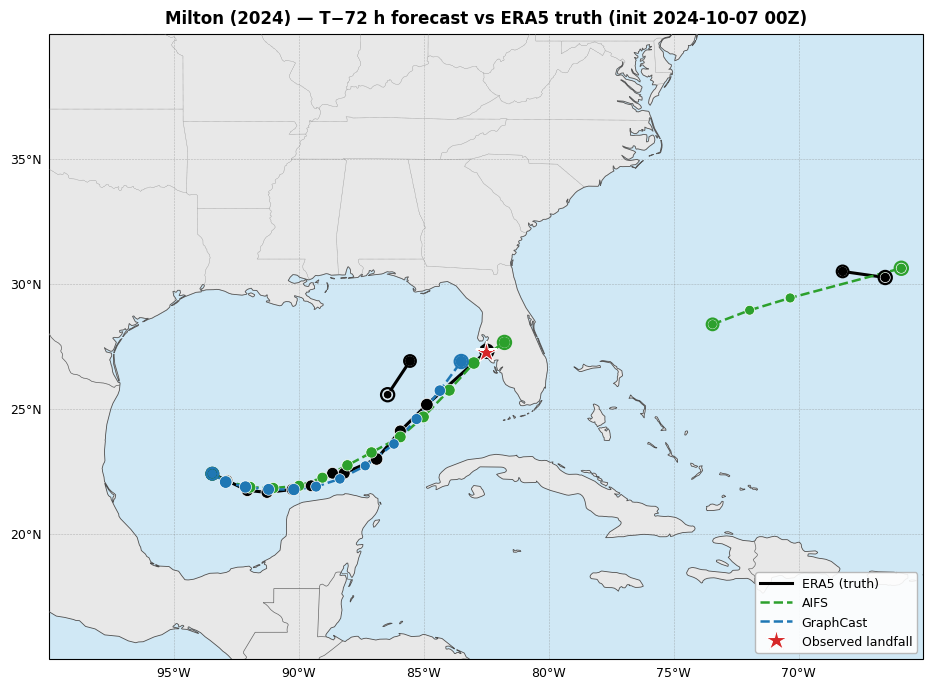

In [45]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_72, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_72, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_72,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−72 h forecast vs ERA5 truth (init {INIT_TIMES[72]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[72],
    nsteps=N_STEPS[72],
    save_path=OUT_DIR / "track_72h.png",
)

In [46]:
df_72 = make_error_table(72, {
    "ERA5 (truth)": era5_tracks_72,
    "AIFS":         aifs_tracks_72,
    "GraphCast":    gc_tracks_72,
})
print(f"\n=== T−72h position error (km) vs ERA5 truth ===\n")
print(df_72.to_string(index=False))


=== T−72h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-07 00Z             0               5764
  10-07 06Z             4               5581
  10-07 12Z            18               5374
  10-07 18Z            33               5176
  10-08 00Z            32               4955
  10-08 06Z            59               4748
  10-08 12Z            71               4532
  10-08 18Z           145               4382
  10-09 00Z           138               4148
  10-09 06Z           112               3945
  10-09 12Z           110               3748
  10-10 00Z            80               3390

saved → outputs/milton/track_168h.png

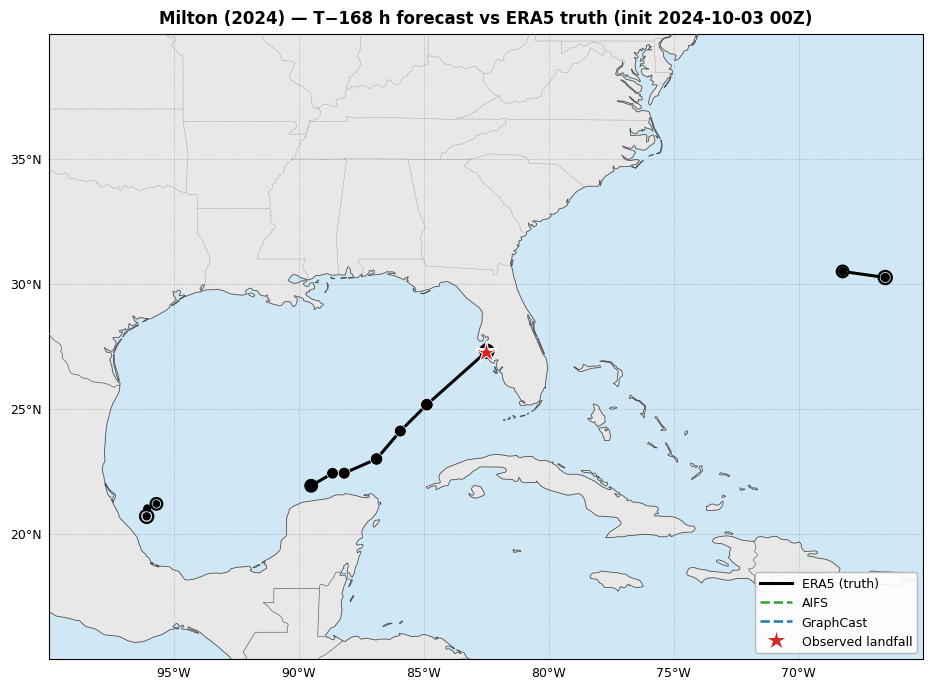

In [47]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_168, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_168, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_168,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−168 h forecast vs ERA5 truth (init {INIT_TIMES[168]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[168],
    nsteps=N_STEPS[168],
    save_path=OUT_DIR / "track_168h.png",
)

In [48]:
df_168 = make_error_table(168, {
    "ERA5 (truth)": era5_tracks_168,
    "AIFS":         aifs_tracks_168,
    "GraphCast":    gc_tracks_168,
})
print(f"\n=== T−168h position error (km) vs ERA5 truth ===\n")
print(df_168.to_string(index=False))


=== T−168h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-08 06Z          1984                 --
  10-08 12Z          2109                 --
  10-08 18Z          2182               1988
  10-09 00Z          2324               2121
  10-09 06Z          2451               2227
  10-09 12Z          2598               2350
  10-10 00Z          2919               2660

saved → outputs/milton/track_240h.png

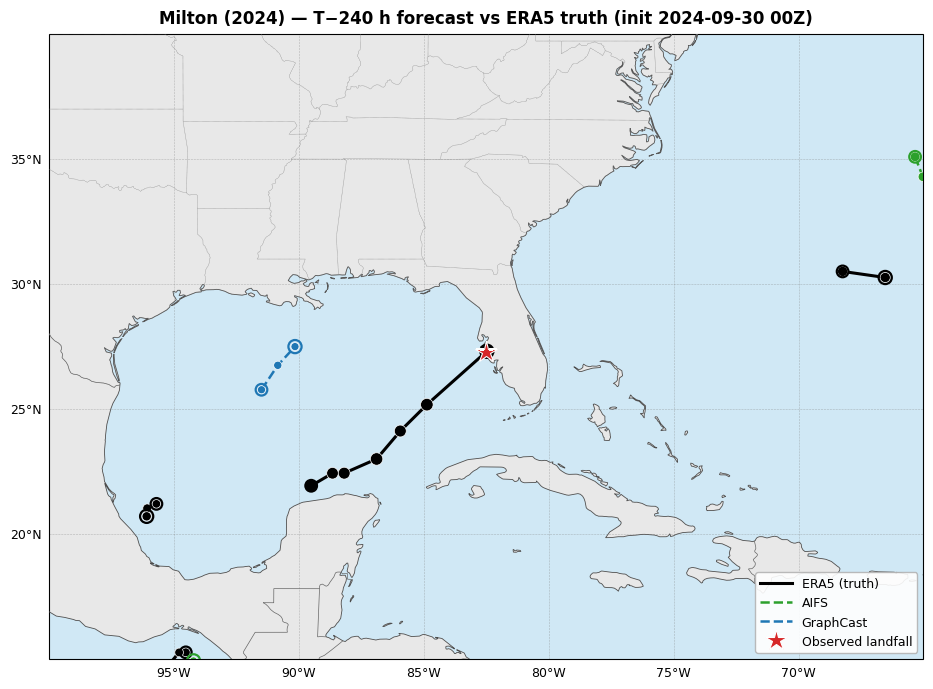

In [49]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_240, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_240, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_240,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−240 h forecast vs ERA5 truth (init {INIT_TIMES[240]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[240],
    nsteps=N_STEPS[240],
    save_path=OUT_DIR / "track_240h.png",
)

In [50]:
df_240 = make_error_table(240, {
    "ERA5 (truth)": era5_tracks_240,
    "AIFS":         aifs_tracks_240,
    "GraphCast":    gc_tracks_240,
})
print(f"\n=== T−240h position error (km) vs ERA5 truth ===\n")
print(df_240.to_string(index=False))


=== T−240h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-08 06Z          1927               4301
  10-08 12Z          2030               4104
  10-08 18Z          2090               3926
  10-09 00Z          2228               3676
  10-09 06Z          2343               3465
  10-09 12Z          2464               3266
  10-10 00Z          2741               2876